In [21]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc

import pandas as pd
import numpy as np

from Functions import calculate_mfi 
from Functions import calculate_rsi
from Functions import get_stock_data

### Calculating MFI

In [22]:
def plot_candlesticks(df, df_with_mfi, df_with_rsi, symbol: str, period=14):

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2]})

    # Prepare data for candlestick
    quotes = []
    for idx, (multi_idx, row) in enumerate(df.iterrows()):
        timestamp = multi_idx[1]
        quotes.append((
            mdates.date2num(timestamp),
            row['open'],
            row['high'],
            row['low'],
            row['close']
        ))

    # Candlestick chart
    candlestick_ohlc(ax1, quotes, width=0.6, colorup='g', colordown='r', alpha=0.8)
    ax1.set_title(f'{symbol} Candlestick Chart')
    ax1.set_ylabel('Price')
    ax1.grid(True)

    # MFI chart
    dates = [multi_idx[1] for multi_idx in df_with_mfi.index]
    ax2.plot(dates, df_with_mfi['mfi'], color='purple', linewidth=1.5)
    # Overbought 
    ax2.axhline(y=80, color='r', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='g', linestyle='--', alpha=0.5)

    # Oversold
    ax2.fill_between(dates, df_with_mfi['mfi'], 80, where=(df_with_mfi['mfi'] >= 80), color='r', alpha=0.3)
    ax2.fill_between(dates, df_with_mfi['mfi'], 20, where=(df_with_mfi['mfi'] <= 20), color='g', alpha=0.3)

    ax2.set_ylabel('MFI')
    ax2.set_ylim(0, 100)
    ax2.grid(True)

    # Plot RSI
    dates = [multi_idx[1] for multi_idx in df_with_rsi.index]
    ax3.plot(dates, df_with_rsi['rsi'], color='blue', linewidth=1.5)
    ax3.axhline(y=70, color='r', linestyle='--', alpha=0.5)  # Overbought line
    ax3.axhline(y=30, color='g', linestyle='--', alpha=0.5)  # Oversold line
    
    # Highlight overbought/oversold regions
    ax3.fill_between(dates, df_with_rsi['rsi'], 70, where=(df_with_rsi['rsi'] >= 70), 
                    color='r', alpha=0.3)  # Highlight overbought
    ax3.fill_between(dates, df_with_rsi['rsi'], 30, where=(df_with_rsi['rsi'] <= 30), 
                    color='g', alpha=0.3)  # Highlight oversold
    
    ax3.set_ylabel('RSI')
    ax3.set_ylim(0, 100)
    ax3.grid(True)

    # Format x-axis with dates
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


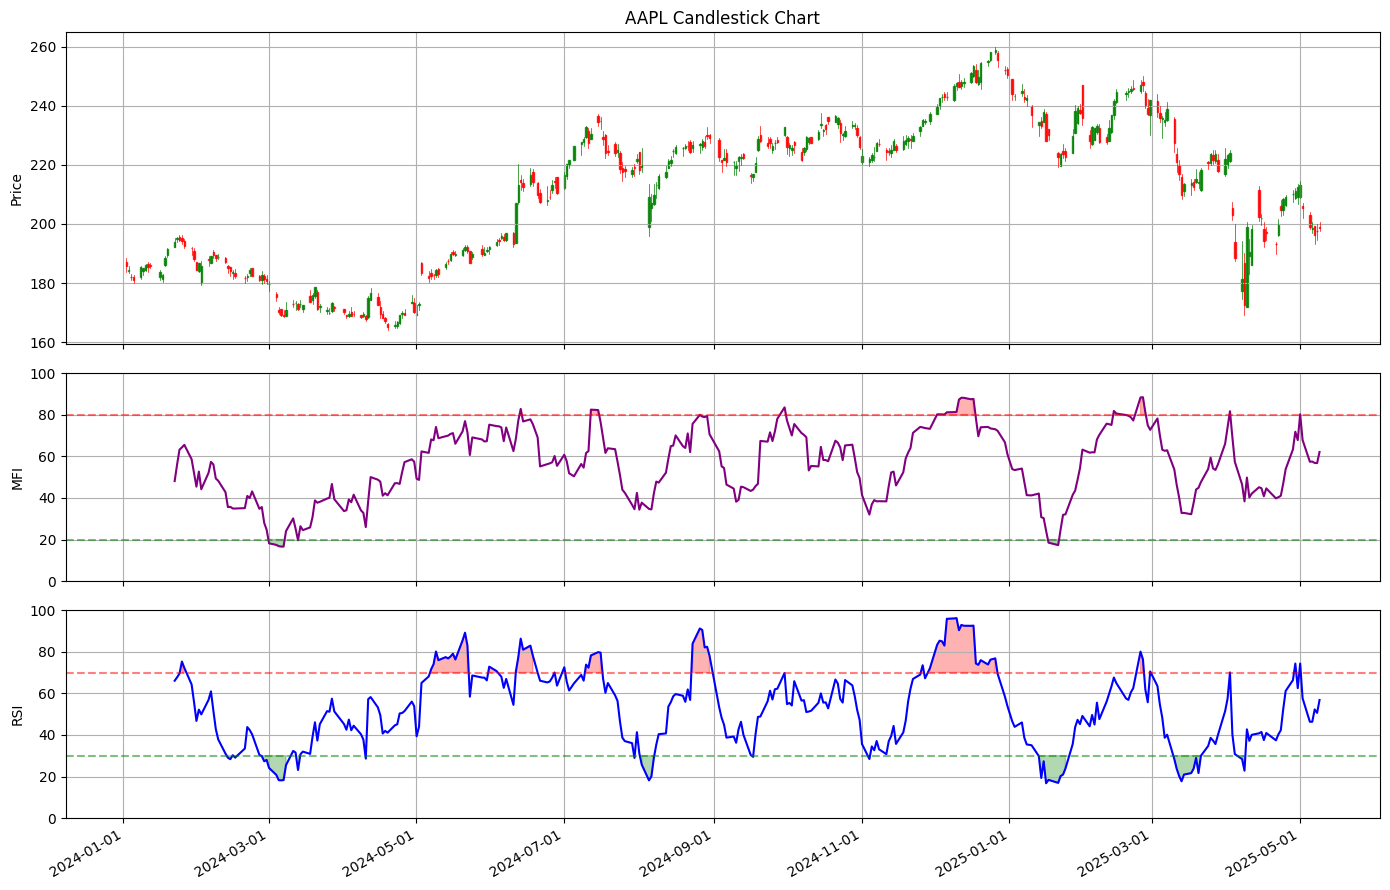

In [23]:
# Example usage
symbol = "AAPL"
start_date = "2024-01-1"
end_date = "2025-05-12"
timeframe_unit = "Day"  # "Day", "Minute", "Hour"
multiplier = 1
# Get stock data
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)

# Calculate MFI
df_with_mfi = calculate_mfi(df)

# Calculate RSI
df_with_rsi = calculate_rsi(df)

# Plot candlestick chart with volume
plot_candlesticks(df, df_with_mfi, df_with_rsi, symbol)